In [19]:
# Importing required libraries for data manipulation, visualization, preprocessing, machine learning model development, evaluation, and model serialization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [20]:
######################################################
# 1. Load Dataset
######################################################

df = pd.read_csv("DATASET.csv")

In [21]:
######################################################
# 2. Clean Data
######################################################

# a. Fix Data Types
df['TOTAL_CHARGES'] = pd.to_numeric(df['TOTAL_CHARGES'], errors='coerce')

# b. Handling Null Values for Numeric Columns
numeric_cols = ['TENURE', 'MONTHLY_CHARGES', 'TOTAL_CHARGES', 'SUPPORT_CALLS']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# c. Handling Null Values for Categorical Columns
if 'DTV_SACHET_WAIVER_ACTIVE' in df.columns:
    df['DTV_SACHET_WAIVER_ACTIVE'] = df['DTV_SACHET_WAIVER_ACTIVE'].fillna(df['DTV_SACHET_WAIVER_ACTIVE'].mode()[0])

df.dropna(subset=['CONTRACT_TYPE', 'PAYMENT_METHOD', 'CHURN'], inplace=True)

# d. Feature Dropping
if 'SUBSCRIBER_ID' in df.columns:
    df.drop('SUBSCRIBER_ID', axis=1, inplace=True)

# e. Categorical Encoding
encoder = LabelEncoder()
categorical_cols = ['CONTRACT_TYPE', 'PAYMENT_METHOD', 'DTV_SACHET_WAIVER_ACTIVE']
for col in categorical_cols:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col])

# f.verify data is fully clean
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TENURE                    2037 non-null   float64
 1   MONTHLY_CHARGES           2037 non-null   float64
 2   TOTAL_CHARGES             2037 non-null   float64
 3   CONTRACT_TYPE             2037 non-null   int64  
 4   PAYMENT_METHOD            2037 non-null   int64  
 5   DTV_SACHET_WAIVER_ACTIVE  2037 non-null   int64  
 6   SUPPORT_CALLS             2037 non-null   float64
 7   CHURN                     2037 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 127.4 KB
None


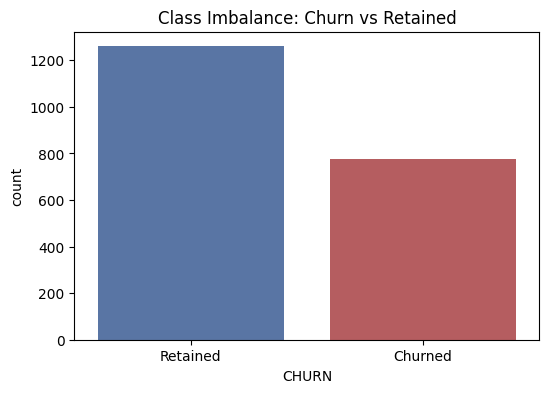

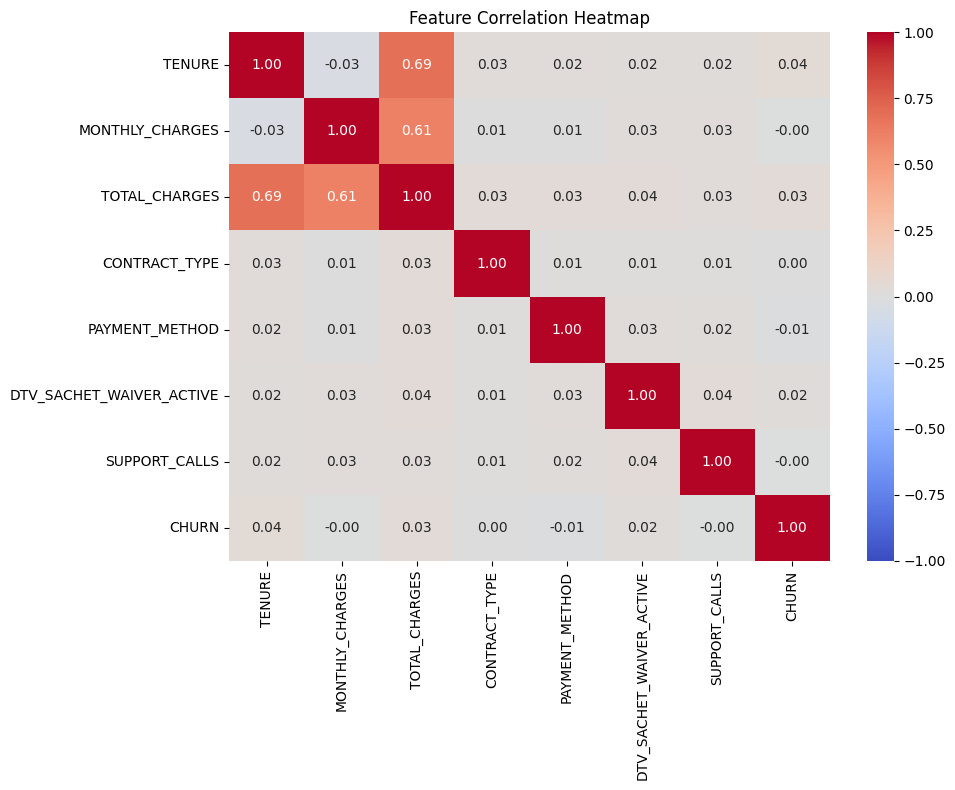

In [22]:
######################################################
# 3. Exploratory Data Analysis (EDA)
######################################################

# a. Churn Class Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='CHURN', data=df, hue='CHURN', palette=['#4C72B0', '#C44E52'])

plt.title('Class Imbalance: Churn vs Retained')
plt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.show()

# b. Feature Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [23]:
######################################################
# 4. Model Implementation & Debugging
######################################################

# a. Feature Definition
X = df.drop(columns=['CHURN', 'SUBSCRIBER_ID'], errors='ignore')
y = df['CHURN']

# b. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# c. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# d. Calculate dynamic class weight for XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ***************** MODELLING *****************

# Model 1: Logistic Regression (Baseline)
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest (Bagging)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Model 3: XGBoost (Advanced Boosting)
xgb_model = XGBClassifier(scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# Model 4: Support Vector Classifier (SVC)
svc_model = SVC(class_weight='balanced', probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train)

# Model 5: Gradient Boosting Classifier
# GBC handles class imbalance natively through sequential tree building
gbc_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_model.fit(X_train_scaled, y_train)

# Model 6: K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()


--- Logistic Regression ---
Accuracy: 0.5147

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       252
           1       0.40      0.51      0.45       156

    accuracy                           0.51       408
   macro avg       0.51      0.51      0.51       408
weighted avg       0.54      0.51      0.52       408

Confusion Matrix (Raw):
[[130 122]
 [ 76  80]] 


--- Random Forest ---
Accuracy: 0.5858

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.85      0.72       252
           1       0.39      0.15      0.22       156

    accuracy                           0.59       408
   macro avg       0.51      0.50      0.47       408
weighted avg       0.53      0.59      0.53       408

Confusion Matrix (Raw):
[[215  37]
 [132  24]] 


--- XGBoost ---
Accuracy: 0.5368

Classification Report:
              precision    recall  f1-score   support

 

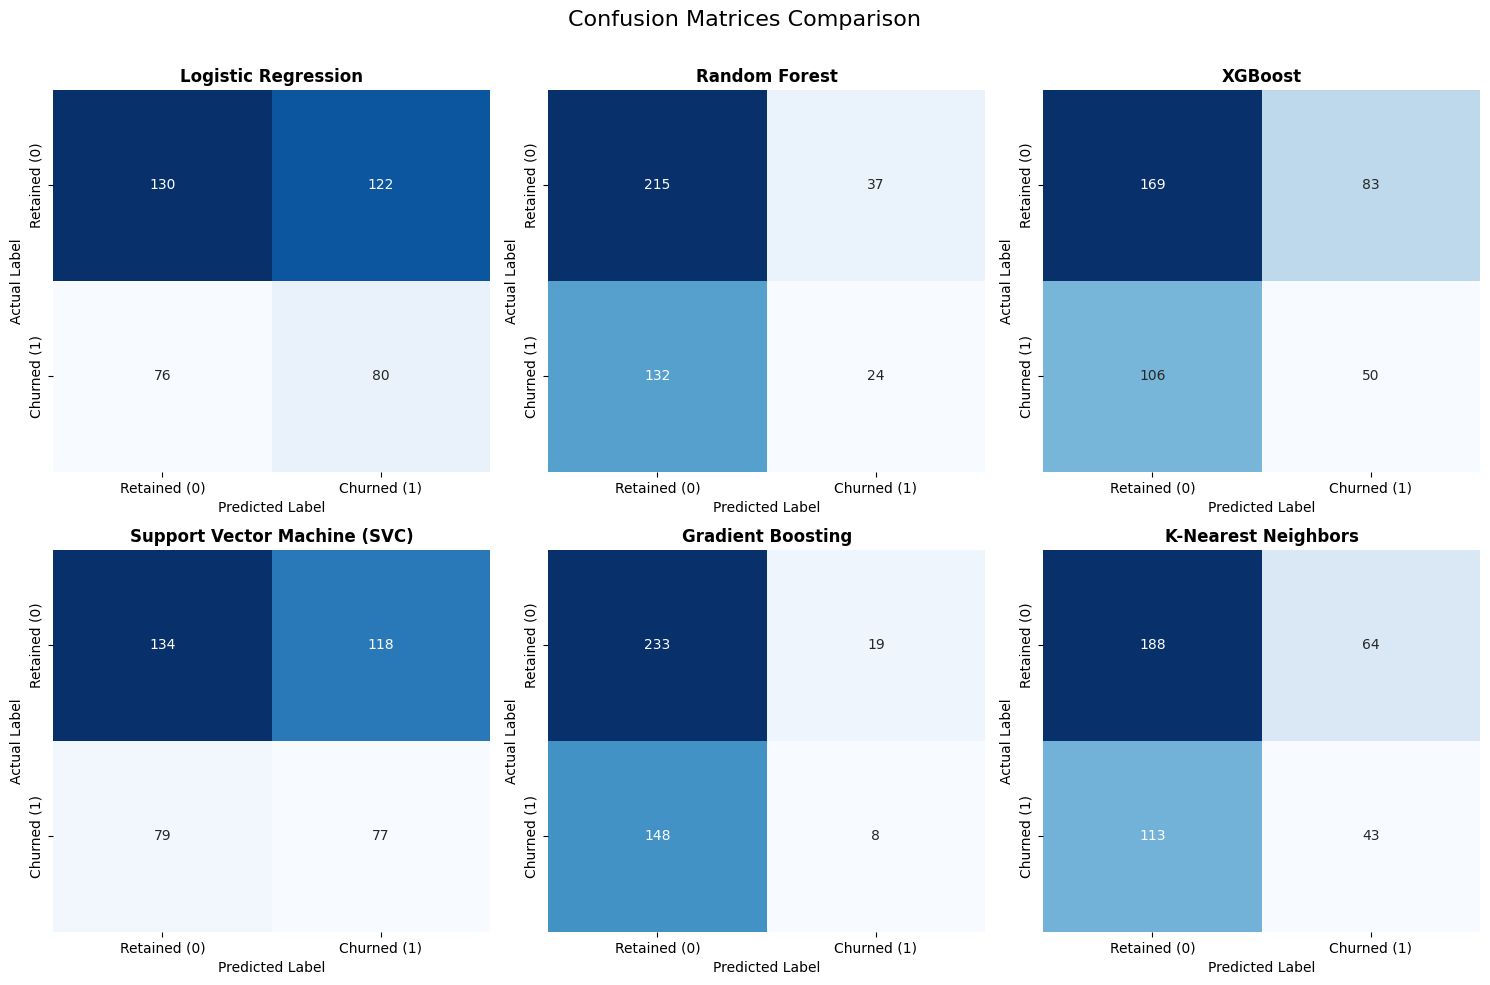

In [24]:
######################################################
# 5. Model Evaluation & Comparison
######################################################

# a. Define the models built
models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Support Vector Machine (SVC)': svc_model,
    'Gradient Boosting': gbc_model,
    'K-Nearest Neighbors': knn_model
}

# b. Text-based Evaluation
for name, model in models.items():
    print(f"\n" + "="*30)
    print(f"--- {name} ---")
    print("="*30)

    y_pred = model.predict(X_test_scaled)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix (Raw):")
    print(confusion_matrix(y_test, y_pred), "\n")


# c. Visual Evaluation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices Comparison', fontsize=16)
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xticklabels(['Retained (0)', 'Churned (1)'])
    axes[i].set_yticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [25]:
######################################################
# 5. Save Model
######################################################

# Based on evaluation, Logistic Regression performed best on Recall for class 1 (Churn)
with open('best_model.pkl', 'wb') as file:

    pickle.dump({
        'model': log_model,
        'scaler': scaler,
        'encoder': encoder
    }, file)

print("Logistic Regression model, scaler, and encoder successfully saved to 'best_model.pkl'")

Logistic Regression model, scaler, and encoder successfully saved to 'best_model.pkl'
